In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pennylane as qml

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    LabelEncoder
)

from sklearn.decomposition import PCA

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
input_file = "selected_healthcare_features.xlsx"

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"File not found: {input_file}\n"
        f"Current folder: {os.getcwd()}"
    )

print("Input file found:")
print(os.path.abspath(input_file))

Input file found:
C:\Users\HOME\project-healthcare\notebooks\selected_healthcare_features.xlsx


In [3]:
excel_file = pd.ExcelFile(input_file)

print("Available sheets:")

for sheet in excel_file.sheet_names:
    print("-", sheet)

required_sheets = [
    "X_Train_Selected",
    "X_Test_Selected",
    "Y_Train",
    "Y_Test"
]

missing_sheets = [
    sheet for sheet in required_sheets
    if sheet not in excel_file.sheet_names
]

if missing_sheets:
    raise ValueError(
        f"Required sheets are missing: {missing_sheets}"
    )

print("\nAll required sheets are available.")

Available sheets:
- X_Train_Selected
- X_Test_Selected
- Y_Train
- Y_Test
- Feature_Scores
- Selection_Quality

All required sheets are available.


In [4]:
X_train = pd.read_excel(
    input_file,
    sheet_name="X_Train_Selected"
)

X_test = pd.read_excel(
    input_file,
    sheet_name="X_Test_Selected"
)

y_train = pd.read_excel(
    input_file,
    sheet_name="Y_Train"
).squeeze("columns")

y_test = pd.read_excel(
    input_file,
    sheet_name="Y_Test"
).squeeze("columns")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (400, 20)
X_test : (100, 20)
y_train: (400,)
y_test : (100,)


In [5]:
if list(X_train.columns) != list(X_test.columns):
    raise ValueError(
        "Training and testing feature columns do not match."
    )

if len(X_train) != len(y_train):
    raise ValueError(
        "X_train and y_train row counts do not match."
    )

if len(X_test) != len(y_test):
    raise ValueError(
        "X_test and y_test row counts do not match."
    )

print("Data structure verified successfully.")

Data structure verified successfully.


In [6]:
forbidden_features = [
    "patient_id",
    "historical_medication_class",
    "recorded_outcome",
    "data_quality_status",
    "measurement_deviation_score"
]

dataset_zscore_features = [
    column for column in X_train.columns
    if column.endswith("_dataset_zscore")
]

forbidden_features += dataset_zscore_features

present_forbidden_features = [
    column for column in forbidden_features
    if column in X_train.columns
]

if present_forbidden_features:
    raise ValueError(
        "Forbidden or leakage features found: "
        f"{present_forbidden_features}"
    )

print("No forbidden or leakage features detected.")

No forbidden or leakage features detected.


In [7]:
non_numeric_columns = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

if non_numeric_columns:
    raise ValueError(
        f"Non-numeric columns found: {non_numeric_columns}"
    )

print("All input features are numerical.")
print("Training missing values:", X_train.isnull().sum().sum())
print("Testing missing values:", X_test.isnull().sum().sum())

All input features are numerical.
Training missing values: 0
Testing missing values: 0


In [8]:
X_train_clean = X_train.replace(
    [np.inf, -np.inf],
    np.nan
).copy()

X_test_clean = X_test.replace(
    [np.inf, -np.inf],
    np.nan
).copy()

training_medians = X_train_clean.median()

X_train_clean = X_train_clean.fillna(
    training_medians
)

X_test_clean = X_test_clean.fillna(
    training_medians
)

print(
    "Remaining training missing values:",
    X_train_clean.isnull().sum().sum()
)

print(
    "Remaining testing missing values:",
    X_test_clean.isnull().sum().sum()
)

Remaining training missing values: 0
Remaining testing missing values: 0


In [9]:
standard_scaler = StandardScaler()

X_train_scaled = standard_scaler.fit_transform(
    X_train_clean
)

X_test_scaled = standard_scaler.transform(
    X_test_clean
)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

print(
    "Scaled training mean:",
    round(X_train_scaled.mean(), 6)
)

print(
    "Scaled training standard deviation:",
    round(X_train_scaled.std(), 6)
)

Scaled training shape: (400, 20)
Scaled testing shape: (100, 20)
Scaled training mean: -0.0
Scaled training standard deviation: 1.0


In [10]:
number_of_qubits = 4

if X_train_scaled.shape[1] < number_of_qubits:
    raise ValueError(
        "Not enough features for the selected qubit count."
    )

pca = PCA(
    n_components=number_of_qubits,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

explained_variance = (
    pca.explained_variance_ratio_.sum()
)

print("Original feature count:", X_train.shape[1])
print("Number of qubits:", number_of_qubits)
print("PCA training shape:", X_train_pca.shape)
print("PCA testing shape:", X_test_pca.shape)

print(
    "Explained variance:",
    round(explained_variance * 100, 2),
    "%"
)

Original feature count: 20
Number of qubits: 4
PCA training shape: (400, 4)
PCA testing shape: (100, 4)
Explained variance: 55.39 %


In [11]:
angle_scaler = MinMaxScaler(
    feature_range=(-np.pi, np.pi)
)

X_train_angles = angle_scaler.fit_transform(
    X_train_pca
)

X_test_angles = angle_scaler.transform(
    X_test_pca
)

X_train_angles = np.clip(
    X_train_angles,
    -np.pi,
    np.pi
)

X_test_angles = np.clip(
    X_test_angles,
    -np.pi,
    np.pi
)

print("Training quantum angles:", X_train_angles.shape)
print("Testing quantum angles:", X_test_angles.shape)

print(
    "Minimum training angle:",
    X_train_angles.min()
)

print(
    "Maximum training angle:",
    X_train_angles.max()
)

Training quantum angles: (400, 4)
Testing quantum angles: (100, 4)
Minimum training angle: -3.141592653589793
Maximum training angle: 3.141592653589793


In [12]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(
    y_train
)

y_test_encoded = label_encoder.transform(
    y_test
)

number_of_classes = len(
    label_encoder.classes_
)

print("Number of target classes:", number_of_classes)

class_mapping = pd.DataFrame({
    "encoded_label": np.arange(
        number_of_classes
    ),
    "historical_medication_class":
        label_encoder.classes_
})

display(class_mapping)

Number of target classes: 12


,encoded_label,historical_medication_class
0,0,Acid-suppression class A
1,1,Acid-suppression class B
2,2,Antidiabetic class A
3,3,Antidiabetic class B
4,4,Antihistamine class A
5,5,Antihistamine class B
6,6,Antihypertensive class A
7,7,Antihypertensive class B
8,8,Bronchodilator class
9,9,Controller inhaler class


In [13]:
quantum_feature_names = [
    f"qubit_angle_{number}"
    for number in range(
        1,
        number_of_qubits + 1
    )
]

X_train_quantum = pd.DataFrame(
    X_train_angles,
    columns=quantum_feature_names
)

X_test_quantum = pd.DataFrame(
    X_test_angles,
    columns=quantum_feature_names
)

y_train_quantum = pd.DataFrame({
    "encoded_target": y_train_encoded,
    "historical_medication_class":
        y_train.reset_index(drop=True)
})

y_test_quantum = pd.DataFrame({
    "encoded_target": y_test_encoded,
    "historical_medication_class":
        y_test.reset_index(drop=True)
})

print("Quantum training data:")
display(X_train_quantum.head())

print("Quantum training target:")
display(y_train_quantum.head())

Quantum training data:


,qubit_angle_1,qubit_angle_2,qubit_angle_3,qubit_angle_4
0,-0.598831,0.069103,-0.905760,-1.111189
1,0.235125,-0.575108,1.067584,-0.684806
2,-0.155145,-0.415917,-0.056228,-0.231365
3,-1.075097,0.781873,-0.880525,-2.169215
4,1.534459,-0.569826,-1.888405,0.128655


Quantum training target:


,encoded_target,historical_medication_class
0,1,Acid-suppression class B
1,10,Lipid-lowering class A
2,5,Antihistamine class B
3,5,Antihistamine class B
4,3,Antidiabetic class B


In [14]:
encoding_quality = pd.DataFrame({
    "check": [
        "Training records",
        "Testing records",
        "Original selected features",
        "Quantum features",
        "Number of qubits",
        "Target classes",
        "Training missing values",
        "Testing missing values",
        "Training infinite values",
        "Testing infinite values"
    ],
    "result": [
        len(X_train_quantum),
        len(X_test_quantum),
        X_train.shape[1],
        X_train_quantum.shape[1],
        number_of_qubits,
        number_of_classes,
        X_train_quantum.isnull().sum().sum(),
        X_test_quantum.isnull().sum().sum(),
        np.isinf(X_train_angles).sum(),
        np.isinf(X_test_angles).sum()
    ]
})

display(encoding_quality)

,check,result
0,Training records,400
1,Testing records,100
2,Original selected features,20
3,Quantum features,4
4,Number of qubits,4
5,Target classes,12
6,Training missing values,0
7,Testing missing values,0
8,Training infinite values,0
9,Testing infinite values,0


In [15]:
quantum_device = qml.device(
    "default.qubit",
    wires=number_of_qubits
)

print("Quantum device created:")
print(quantum_device)

Quantum device created:
<default.qubit device (wires=4) at 0x1d35606ee50>


In [16]:
@qml.qnode(quantum_device)
def quantum_encoding_circuit(features):

    qml.AngleEmbedding(
        features=features,
        wires=range(number_of_qubits),
        rotation="Y"
    )

    return [
        qml.expval(qml.PauliZ(wire))
        for wire in range(number_of_qubits)
    ]

In [17]:
sample_angles = X_train_angles[0]

quantum_output = quantum_encoding_circuit(
    sample_angles
)

print("Input angles:")
print(sample_angles)

print("\nQuantum circuit output:")
print(quantum_output)

print("\nOutput count:", len(quantum_output))

Input angles:
[-0.59883077  0.06910302 -0.90576017 -1.11118872]

Quantum circuit output:
[np.float64(0.825995248725415), np.float64(0.997613336027594), np.float64(0.6170875878341464), np.float64(0.44359646732901564)]

Output count: 4


In [18]:
print(
    qml.draw(
        quantum_encoding_circuit
    )(sample_angles)
)

0: ─╭AngleEmbedding(M0)─┤  <Z>
1: ─├AngleEmbedding(M0)─┤  <Z>
2: ─├AngleEmbedding(M0)─┤  <Z>
3: ─╰AngleEmbedding(M0)─┤  <Z>

M0 = 
[-0.59883077  0.06910302 -0.90576017 -1.11118872]


In [19]:
quantum_test_outputs = []

for row_number in range(5):

    result = quantum_encoding_circuit(
        X_train_angles[row_number]
    )

    quantum_test_outputs.append(result)

quantum_test_outputs_df = pd.DataFrame(
    quantum_test_outputs,
    columns=[
        f"qubit_{number}_expectation"
        for number in range(
            1,
            number_of_qubits + 1
        )
    ]
)

display(quantum_test_outputs_df)

,qubit_1_expectation,qubit_2_expectation,qubit_3_expectation,qubit_4_expectation
0,0.825995,0.997613,0.617088,0.443596
1,0.972485,0.839134,0.482242,0.774541
2,0.987989,0.914746,0.998420,0.973354
3,0.475647,0.709595,0.636746,-0.563336
4,0.036329,0.841995,-0.312296,0.991735


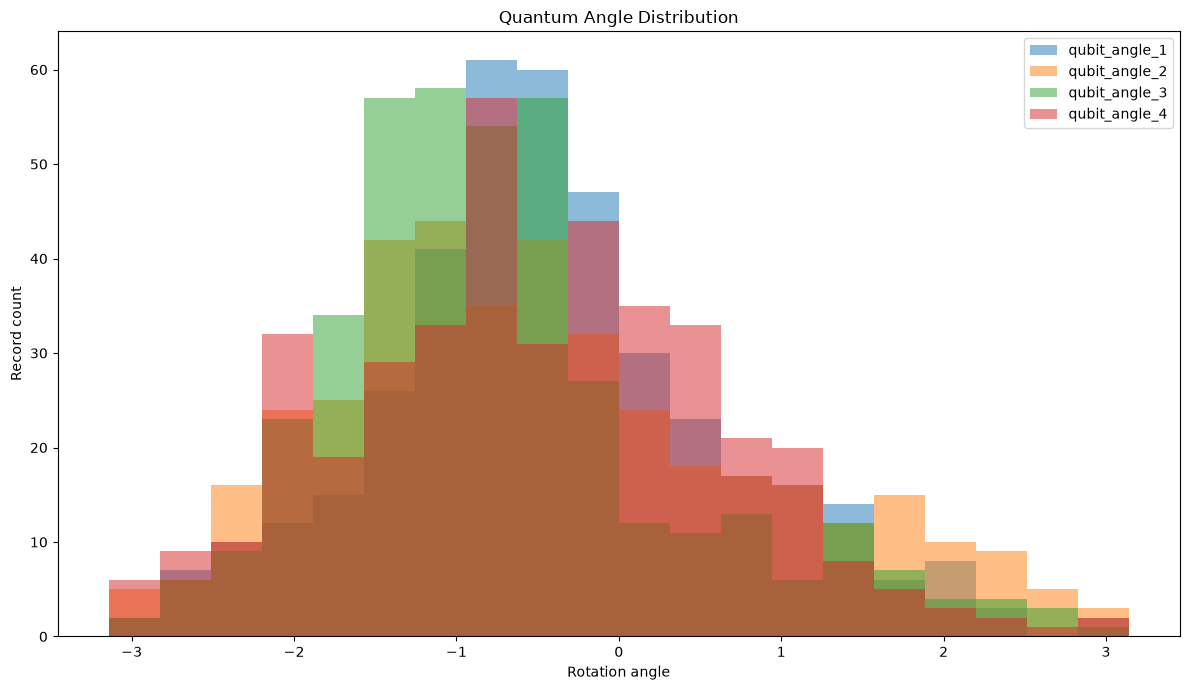

In [20]:
plt.figure(figsize=(12, 7))

for feature in quantum_feature_names:

    plt.hist(
        X_train_quantum[feature],
        bins=20,
        alpha=0.5,
        label=feature
    )

plt.title("Quantum Angle Distribution")
plt.xlabel("Rotation angle")
plt.ylabel("Record count")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
output_file = "quantum_encoded_healthcare_data.xlsx"

pca_summary = pd.DataFrame({
    "quantum_component": [
        f"component_{number}"
        for number in range(
            1,
            number_of_qubits + 1
        )
    ],
    "explained_variance_ratio":
        pca.explained_variance_ratio_
})

with pd.ExcelWriter(
    output_file,
    engine="openpyxl"
) as writer:

    X_train_quantum.to_excel(
        writer,
        sheet_name="X_Train_Quantum",
        index=False
    )

    X_test_quantum.to_excel(
        writer,
        sheet_name="X_Test_Quantum",
        index=False
    )

    y_train_quantum.to_excel(
        writer,
        sheet_name="Y_Train",
        index=False
    )

    y_test_quantum.to_excel(
        writer,
        sheet_name="Y_Test",
        index=False
    )

    class_mapping.to_excel(
        writer,
        sheet_name="Class_Mapping",
        index=False
    )

    encoding_quality.to_excel(
        writer,
        sheet_name="Encoding_Quality",
        index=False
    )

    pca_summary.to_excel(
        writer,
        sheet_name="PCA_Summary",
        index=False
    )

print("Quantum-encoded dataset saved:")
print(os.path.abspath(output_file))

Quantum-encoded dataset saved:
C:\Users\HOME\project-healthcare\notebooks\quantum_encoded_healthcare_data.xlsx


In [22]:
quantum_encoding_pipeline = {
    "input_feature_columns":
        X_train.columns.tolist(),
    "training_medians":
        training_medians,
    "standard_scaler":
        standard_scaler,
    "pca":
        pca,
    "angle_scaler":
        angle_scaler,
    "label_encoder":
        label_encoder,
    "number_of_qubits":
        number_of_qubits,
    "number_of_classes":
        number_of_classes,
    "quantum_feature_names":
        quantum_feature_names
}

pipeline_file = "quantum_encoding_pipeline.pkl"

joblib.dump(
    quantum_encoding_pipeline,
    pipeline_file
)

print("Encoding pipeline saved:")
print(os.path.abspath(pipeline_file))

Encoding pipeline saved:
C:\Users\HOME\project-healthcare\notebooks\quantum_encoding_pipeline.pkl


In [23]:
saved_file = pd.ExcelFile(
    output_file
)

print("Saved workbook sheets:")

for sheet in saved_file.sheet_names:
    print("-", sheet)

check_train = pd.read_excel(
    output_file,
    sheet_name="X_Train_Quantum"
)

check_test = pd.read_excel(
    output_file,
    sheet_name="X_Test_Quantum"
)

assert check_train.shape == (400, 4)
assert check_test.shape == (100, 4)
assert check_train.isnull().sum().sum() == 0
assert check_test.isnull().sum().sum() == 0

print("\nQuantum Data Encoding completed successfully.")
print("Training shape:", check_train.shape)
print("Testing shape:", check_test.shape)

Saved workbook sheets:
- X_Train_Quantum
- X_Test_Quantum
- Y_Train
- Y_Test
- Class_Mapping
- Encoding_Quality
- PCA_Summary

Quantum Data Encoding completed successfully.
Training shape: (400, 4)
Testing shape: (100, 4)


In [24]:
check_y_train = pd.read_excel(
    output_file,
    sheet_name="Y_Train"
)

check_y_test = pd.read_excel(
    output_file,
    sheet_name="Y_Test"
)

assert check_y_train.shape[0] == 400
assert check_y_test.shape[0] == 100
assert check_y_train["encoded_target"].nunique() == 12

print("Target encoding verified successfully.")

Target encoding verified successfully.
